In [55]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [56]:
from typing import TypedDict,Annotated,List,Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel,Field
from langgraph.graph import END,StateGraph,START
from typing import List
import operator

#### State(Reflection)

In [57]:
grades=Literal[
    "ultra-conservative",
    "conservative",
    "moderate",
    "aggressive",
    "high risk"
]

class State(TypedDict):
    investment_plan:str
    investor_profile:str
    target_grade:grades
    feedback:str
    grade:grades
    n:int=0

- `investment_plan`: Our generated plan that will be evaluated and revised if need be
- `investor_profile`: The user inputted profile that we'll use as a reference for the plan
- `target_grade`: A generated ideal risk tolerance grade based on the investor profile
- `feedback`: Evaluator feedback for the investment plan
- `grade`: Evaluated grade of the investment plan
- `n`: Number of evaluation iterations

**Note:** Both grade fields are `Literal` meaning they can only take a value within the defined list.


#### Setup Node

In [58]:
grade_prompt=ChatPromptTemplate.from_messages([
    ("system",
     "You are an investor advisor. Given the investor's profile and their proposed plan,"
     "choose exactly one risk classifications from: ultra-conservative, conservative, moderate, aggressive, high-risk."
     "Return ONLY the grade"
    ),
    ("user",
     "Investor profile:\n\n{investor_profile}\n\n"
    )
])

grade_pipe=grade_prompt | llm

In [59]:
def determine_target_grade(state:State):
    """Ask the llm to pick the best-fitting target grade"""
    response=grade_pipe.invoke({
        "investor_profile":state["investor_profile"]
    })
    # return as a plain dict so langGraph can merge it into the state
    return {"target_grade":response.content.lower()}

In [60]:
# initiate empty state for the user inputted investor profile

dummy_state:State={
    "investment_plan":"",
    "investor_profile":(
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerence: High"
    ),
    "target_grade": "",
    "feedback": "",
    "grade": "",
    "n": 0
}

In [61]:
from pprint import pprint
# get target grade 
target_grade= determine_target_grade(dummy_state)
# update target grade with the returned dict
dummy_state.update(target_grade)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': '',
 'investor_profile': 'Age: 29\n'
                     'Salary: $110,000\n'
                     'Assets: $40,000\n'
                     'Goal: Achieve financial independence by age 45\n'
                     'Risk tolerence: High',
 'n': 0,
 'target_grade': 'aggressive'}


#### Generator Node

##### Phase 1: Initial Generation

In [62]:
# initial generation, no feedback, only based on profile
cathie_wood_prompt=ChatPromptTemplate.from_messages([
    ("system",
     """You are a bold, innovation-driven investment advisor inspired by Cathie wood
     Your goal is to generate a high-conviction, forward-looking investment plan that embrace disruptive technologies,
     emerging markets, and long-term growth potential. You are not afraid of short-term volatility as long as the upside is transformational.
     
     Create an  strategy tailored to the investor profile below. Prioritize innovation and high-reward opportunities,
     such as arificial intelligence, biotechology, blockchain, or renewable energy.

     Respond with a concise investment plan in paragraph form
    
     """
    ),
    ("user", "Investor Profile:\\n{investor_profile}"
    )
])

cathie_wood_pipe=cathie_wood_prompt | llm

In [63]:
# evaluator output schema
class Feedback(BaseModel):
    grade:grades=Field(description="Classify the investment based on risk level, ranging from ultra-conservative to high risk.")
    feedback: str=Field(description="Provide reasoning for the risk classifications assigned to the investment suggestions")

##### Phase 2: Adaptive Generation

In [64]:
ray_dailo_prompt=ChatPromptTemplate.from_messages([
    ("system",
    """
    You are an investment advisor inspired by Ray Dailo's principle but with adative strategy generation.
    Your goal is to create varied, scenario-aware investment plans that respond dynamically to economic conditions,feedback, and the investor's evolving needs.
    You adapt your recommendations based on previous evaluations.
    
    CORE PRINCIPLES:
    - Evnironmental diversification across economic regimes (growth/inflation combinations)
    - Risk Parity weighting by volatility, not just dollar amounts
    - Inflation-aware asset selections with real return focus
    - Macroeconomic scenario planning and regime identifications
    
    ADAPTATIONS RULES based on feedback:
    - if deemed "too conservative" -> Increase growth equity allocations, add emerging markets, consider alternatives
    - if deemed "too agressive" -> Add defensive assets, increase bond allocations, focus on dividend stocks
    - if "lacks  inflation protection"-> Emphasize TIPS, commodities, REITs, international exposure
    - if "too complex"-> Simplify to core ETF strategy with clear rationale
    - if "insufficient diversification" -> Add geographic, sector, or alternative asset exposure
    
    ECONOMIC SCENARIO ADJUSTMENTS:
    - Rising inflation environment-> Emphasize commodities, TIPS, real estate, reduce duration
    - Stagflation concerns-> Focus on energy, materials, international markets, inflation hedges
    - Deflationary risks-> Increase government bonds, high-quality corporate bonds, cash positions
    - Growth acceleration-> Favor technology, consumer discretionary, small-cap growth
    - Economic uncertainity-> Balance with "All Weather" approach using multiple asset classes
    
    TARGETING 15% RETURNS through:
    - Stragegic Overweighting of growth assets during favorable conditions
    - Tactical allocations adjustment based on economic regime
    - Alternaive investment(REITs,commodities, international) 
    - Leverage consideration for qualified investors
    - Reguar re balancing to c apture volatility
    """  
    ),
    ("human",
     """Investor profile:
        {investor_profile}

        Previous strategy grade: {grade}

        Evaluator feedback: {feedback}

        Based on this feedback, create a NEW investment strategy 
        that addresses the concerns raised 
        while targeting 15% returns. Make significant adjustments 
        from any previous approach.
    """)
    
])


ray_dailo_pipe=ray_dailo_prompt | llm



#### Build the Generator Node

In [65]:
def investment_plan_generator(state:State)->dict:
    """Prompts an LLM to generate or improve an investment plan based on the current state"""
    if state.get("feedback"):
        # use Ray Dalio-style generator when feedback is available
        response=ray_dailo_pipe.invoke({
            "investor_profile":state["investor_profile"],
            "grade":state["grade"],
            "Feedback":state["feedback"]    
        })
    else: 
    # use Cathie Wood-Style generator for initial plan
        response= cathie_wood_pipe.invoke({
            "investor_profile":state['investor_profile']
        })
    
    return {"investment_plan":response.content}
        

In [66]:
# get the investment plan
initial_investment_plan=investment_plan_generator(dummy_state)
# update the dummy state with generate plan
dummy_state.update(initial_investment_plan)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': '**Disruptive Innovation Wealth-Building Plan**\n'
                    '\n'
                    'At 29 with 16 years until financial independence, a high '
                    'risk tolerance, and a $110K salary, you have the ideal '
                    'profile to pursue a Cathie Wood-style innovation strategy '
                    'that prioritizes exponential growth over capital '
                    'preservation. Your portfolio should be aggressively '
                    'tilted toward the five innovation platforms reshaping the '
                    'global economy: **Artificial Intelligence (30%)**, '
                    '**Biotechnology & Genomics (20%)**, **Blockchain & '
                    'Digital Assets (15%)**, **Robotics & Automation (15%)**, '
                    'and **Energy Innovation (10%)**, with the remaining **10% '
                    'in cash** to opportunistically add during market '
                    'draw

##### Evaluator Node

In [67]:
# Warren Buffet style evaluation prompt
evaluator_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """You are an investment risk evaluator inspired by Warren Buffett's value investing philosophy.

Your task is to assess whether a proposed investment strategy aligns with conservative, value-driven principles 
that emphasize capital preservation, long-term stability, and sound business fundamentals. You should be 
skeptical of speculative investments, high-volatility assets, and short-term market trends.

RISK CLASSIFICATION LEVELS:
- ultra-conservative: Extremely safe, minimal risk of loss
- conservative: Low risk, prioritizes capital preservation  
- moderate: Balanced approach with acceptable risk-reward ratio
- aggressive: Higher risk for potentially greater returns
- high risk: Speculative investments with significant loss potential

EVALUATION CRITERIA:
- Business clarity: Is the investment easily understandable with transparent cash flows?
- Margin of safety: Does the investment price provide protection against downside risk?
- Capital preservation: Will this strategy protect wealth over the long term?
- Investor alignment: Does this match a conservative investor's risk tolerance and goals?
- Quality fundamentals: Are the underlying assets financially sound with competitive advantages?

Return your assessment in the following  format:
{{
  "grade": "<investment risk level>",
  "feedback": "<concise explanation of the assigned risk level and key reasoning>"
}}
"""
    ),
    ("human", 
     "Evaluate this investment plan:\n\n{investment_plan}\n\nFor this investor profile:\n\n{investor_profile}\n\nAnd provide feedback that matches this target risk level: {target_grade}")
])

# create the pipe with the structured output that outputs a Feedback object
buffett_evaluator_pipe = evaluator_prompt | llm.with_structured_output(Feedback)

#### Build the Generator Node

In [68]:
def evaluate_plan(state: State):
    """LLM evaluates the investment plan"""

    # add one to the current count
    current_count = state.get('n', 0) + 1

    # get the evaluation result from the evaluator pipe
    evaluation_result = buffett_evaluator_pipe.invoke({
        "investment_plan": state["investment_plan"],
        "investor_profile": state["investor_profile"],
        "target_grade": state["target_grade"]
    })

    # return the grade and feedback in a dict
    return {"grade": evaluation_result.grade, "feedback": evaluation_result.feedback, "n": current_count}

In [69]:
# get the feedback
evaluated_feedback = evaluate_plan(dummy_state)
# update the dummy state with the feedback
dummy_state.update(evaluated_feedback)

In [70]:
pprint(f"Grade: {dummy_state['grade']}")
pprint(f"Feedback: {dummy_state['feedback']}")

'Grade: aggressive'
('Feedback: This plan is squarely aggressive by virtually every measure. It '
 'explicitly deprioritizes capital preservation in favor of exponential '
 'growth, concentrates 90% of assets across five highly volatile, speculative '
 'innovation sectors (AI, biotech, blockchain, robotics, energy), and '
 'discourages defensive repositioning during drawdowns—advice that '
 'historically has destroyed capital for trend-chasing investors. The Cathie '
 'Wood-style anchor (ARKK) has experienced drawdowns exceeding 75% from peak '
 "to trough, which would test even a high-tolerance investor's resolve, and "
 'the inclusion of blockchain/digital assets and early-stage biotech/CRISPR '
 'names adds substantial binary-event risk. Projections of $1.2M–$3M+ rely on '
 'sustained outsized returns from sectors that are prone to hype cycles, '
 'regulatory shocks, and valuation compression when rates rise. While the age, '
 'income, savings rate, and 16-year horizon do provide so

#### Routing Node

In [71]:
def route_investment(state: State, iteration_limit: int = 5):
    """Route investment based on risk grade evaluation"""
    # get grades
    current_grade = state.get("grade", "MISSING")
    target_grade = state.get("target_grade", "MISSING")
    # check if grades match
    match = current_grade == target_grade

    # print out the tracked values
    print(f"=== ROUTING  ===")
    print(f"Current grade: '{current_grade}'")
    print(f"Target risk profile: '{target_grade}'")
    print(f"Match: {match}")
    print(f"Number of trials: {state['n']}")

    # routing logic
    if match: # grades match
        print("→ Routing to: Accepted")
        return "Accepted"
    elif state['n'] > iteration_limit: # review iterations exceeds limit
        print("→ Too many iterations, stopping")
        return "Accepted"
    else: # grades don't match
        print("→ Routing to: Rejected + Feedback")
        return "Rejected + Feedback"

#### Building the workflow(Reflection)

In [72]:
# initialize StateGraph with the given State schema
optimizer_builder = StateGraph(State)

# add the setup, generator, and evaluator nodes
optimizer_builder.add_node("determine_target_grade", determine_target_grade)
optimizer_builder.add_node("investment_plan_generator", investment_plan_generator)
optimizer_builder.add_node("evaluate_plan", evaluate_plan)

# define the flow with edges
optimizer_builder.add_edge(START, "determine_target_grade")
optimizer_builder.add_edge("determine_target_grade", "investment_plan_generator")
optimizer_builder.add_edge("investment_plan_generator", "evaluate_plan")

#### Conditional Routing

In [73]:
# add conditional edge for reflection
optimizer_builder.add_conditional_edges(
    "evaluate_plan",
    lambda state: route_investment(state),
    {
        "Accepted": END,
        "Rejected + Feedback": "investment_plan_generator",
    },
)

In [74]:
# compile the workflow
optimizer_workflow = optimizer_builder.compile()

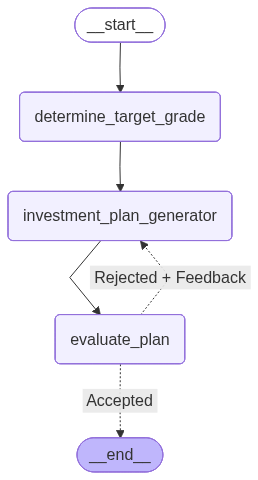

In [75]:
# display the graph
from IPython.display import Image,display
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

#### Testing(Reflection)

In [76]:
# invoke the workflow with an example investor profile
state = optimizer_workflow.invoke({
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    )
})

=== ROUTING  ===
Current grade: 'aggressive'
Target risk profile: 'aggressive'
Match: True
Number of trials: 1
→ Routing to: Accepted


In [77]:
def pretty_print_final_state(state: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Investor Profile:\n{state['investor_profile']}")
    
    print("\n📈 Target Risk Grade:", state['target_grade'])
    print("📊 Final Assigned Grade:", state['grade'])
    print("🔁 Iterations Taken:", state['n'])

    print("\n📝 Evaluator Feedback:\n" + "-"*30)
    print(state['feedback'])

    print("\n📃 Final Investment Plan:\n" + "-"*30)
    print(state['investment_plan'])

pretty_print_final_state(state)

🎯 Final Investment Plan Summary

📌 Investor Profile:
Age: 29
Salary: $110,000
Assets: $40,000
Goal: Achieve financial independence by age 45
Risk tolerance: High

📈 Target Risk Grade: aggressive
📊 Final Assigned Grade: aggressive
🔁 Iterations Taken: 1

📝 Evaluator Feedback:
------------------------------
This portfolio sits squarely in aggressive territory and arguably brushes against high-risk/speculative classification due to several features: (1) 70% concentration in thematic innovation ETFs (ARKK/ARKW/ARKG) that have historically exhibited 50–80% peak-to-trough drawdowns and trade at multiples disconnected from current cash flows; (2) 15% direct crypto exposure, an asset class with no cash flows, no intrinsic yield, and extreme volatility; and (3) 10% in individual moonshots where binary outcomes (including total loss) are explicitly accepted. The 5% cash buffer is thin for a portfolio prone to severe drawdowns. Strengths for an aggressive profile: the 16-year horizon genuinely sup